In [9]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configurações de visualização
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
current_dir = os.getcwd()

# Carregar o dataset
try:
    df = pd.read_csv('../data/raw/cybersecurity_logs.csv')
    print("Dataset carregado com sucesso!")
except FileNotFoundError:
    print("Erro: O arquivo 'cybersecurity_logs.csv' não foi encontrado.")
    print("Por favor, baixe o dataset e coloque-o no diretório 'data/raw/'.")

# Exibir as primeiras linhas e informações básicas
if 'df' in locals():
    print("\n--- Primeiras 5 linhas do dataset ---")
    print(df.head())
    print("\n--- Informações do DataFrame ---")
    df.info()

Dataset carregado com sucesso!

--- Primeiras 5 linhas do dataset ---
             Timestamp      IP_Address Request_Type  Status_Code  \
0  2023-01-01 00:00:00  202.118.116.11          GET          403   
1  2023-01-01 00:01:00    38.30.40.178       DELETE          301   
2  2023-01-01 00:02:00    209.5.148.15         POST          500   
3  2023-01-01 00:03:00   211.116.60.71          GET          301   
4  2023-01-01 00:04:00  170.166.36.145         POST          404   

   Anomaly_Flag User_Agent  Session_ID Location  
0             0       Edge        4835   Brazil  
1             0        Bot        3176    China  
2             0      Opera        4312    China  
3             0        Bot        1003   France  
4             0    Firefox        1428  Germany  

--- Informações do DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ---


--- Análise Exploratória de Dados (EDA) ---

Valores ausentes por coluna:
Timestamp       0
IP_Address      0
Request_Type    0
Status_Code     0
Anomaly_Flag    0
User_Agent      0
Session_ID      0
Location        0
dtype: int64

Distribuição da classe 'Anomaly_Flag':
Anomaly_Flag
0    9510
1     490
Name: count, dtype: int64


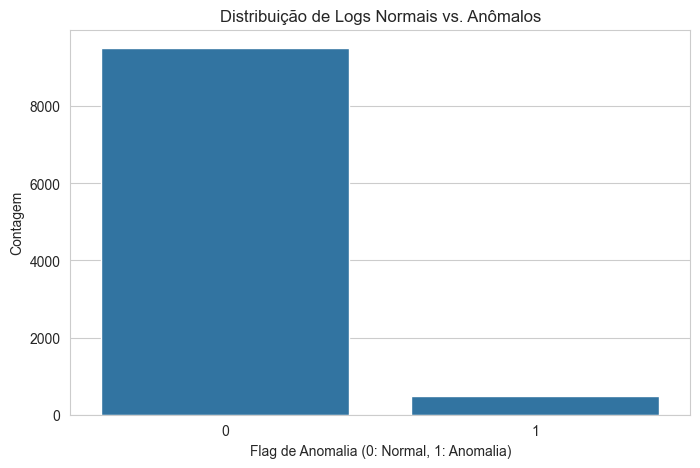

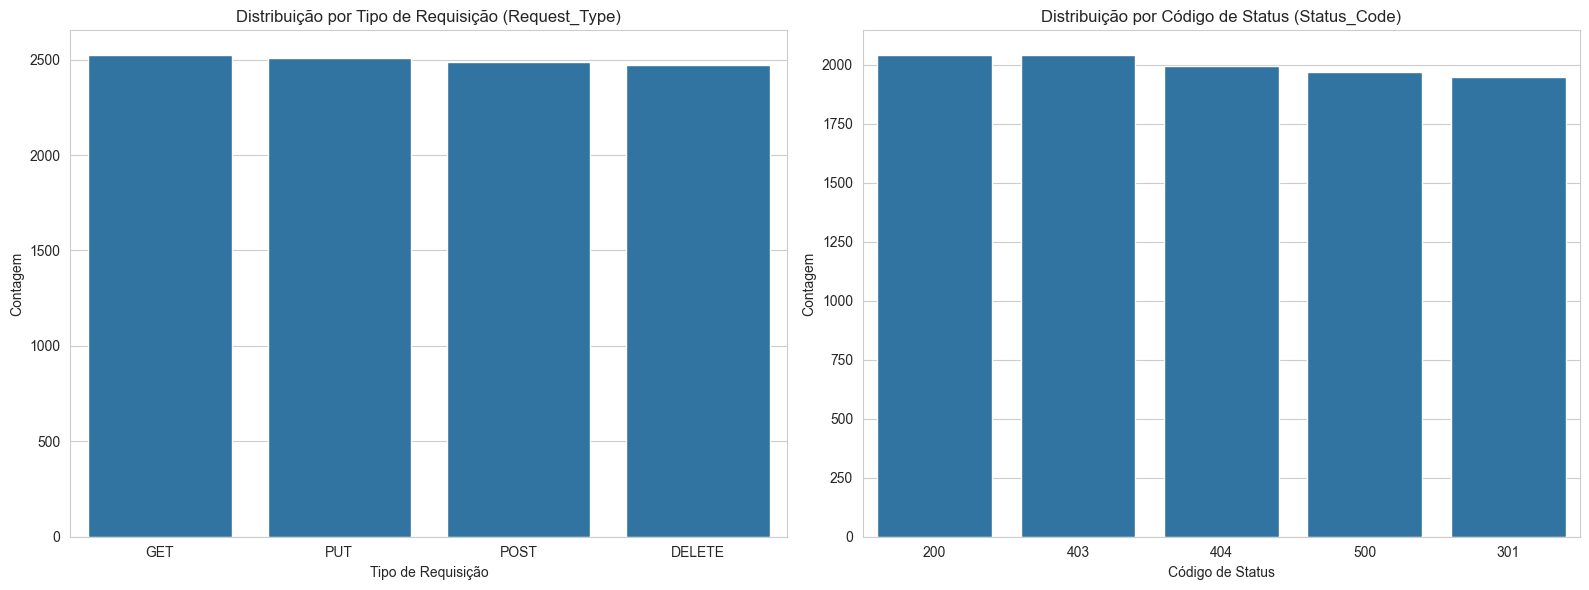

In [13]:
if 'df' in locals():
    print("\n--- Análise Exploratória de Dados (EDA) ---")

    # 1. Verificar valores ausentes
    print("\nValores ausentes por coluna:")
    print(df.isnull().sum())

    # 2. Analisar a variável alvo 'Anomaly_Flag'
    print("\nDistribuição da classe 'Anomaly_Flag':")
    anomaly_counts = df['Anomaly_Flag'].value_counts()
    print(anomaly_counts)

    # Visualizar a distribuição da classe
    plt.figure(figsize=(8, 5))
    sns.countplot(x='Anomaly_Flag', data=df)
    plt.title('Distribuição de Logs Normais vs. Anômalos')
    plt.xlabel('Flag de Anomalia (0: Normal, 1: Anomalia)')
    plt.ylabel('Contagem')
    plt.show()

    # 3. Analisar features categóricas
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico para 'Request_Type'
    order_request = df['Request_Type'].value_counts().index.tolist()
    sns.countplot(ax=axes[0], x='Request_Type', data=df, order=order_request)
    axes[0].set_title('Distribuição por Tipo de Requisição (Request_Type)')
    axes[0].set_xlabel('Tipo de Requisição')
    axes[0].set_ylabel('Contagem')

    # Gráfico para 'Status_Code'
    order_status = df['Status_Code'].value_counts().index.tolist()
    sns.countplot(ax=axes[1], x='Status_Code', data=df, order=order_status)
    axes[1].set_title('Distribuição por Código de Status (Status_Code)')
    axes[1].set_xlabel('Código de Status')
    axes[1].set_ylabel('Contagem')

    plt.tight_layout()
    plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction import FeatureHasher
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

# Supondo que df já foi lido corretamente

# 1. Feature engineering temporal
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['hour'] = df['Timestamp'].dt.hour
df['minute'] = df['Timestamp'].dt.minute
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['new_session'] = (
    (df['IP_Address'] != df['IP_Address'].shift()) |
    ((df['Timestamp'] - df['Timestamp'].shift()) > pd.Timedelta('5m'))
)
df['session_id'] = df['new_session'].cumsum()
df['time_since_last'] = df.groupby('session_id')['Timestamp'].diff().dt.total_seconds().fillna(0)
df['count_in_session'] = df.groupby('session_id').cumcount() + 1
df['event_rate_per_minute'] = df['count_in_session'] / (df['time_since_last'].cumsum() / 60 + 1e-6)

# 2. Definição das colunas
numeric_features = [
    'hour','minute','day_of_week',
    'time_since_last','event_rate_per_minute'
]
categorical_features_low = ['Method', 'Status_Code']  # poucas categorias (ex: GET, POST, 200, 404)
categorical_features_high = ['URI']  # alta cardinalidade (muitas URIs únicas)

# 3. Pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer_low = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

categorical_transformer_high = Pipeline(steps=[
    ('hasher', FeatureHasher(n_features=10, input_type='string'))
])

high_cat = ['IP_Address','URI','User_Agent']
cast_str = FunctionTransformer(lambda X: X.astype(str).values)
cat_high = Pipeline([
    ('astype', cast_str),
    ('hasher', FeatureHasher(n_features=32, input_type='string'))
])

text_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        min_df=5, max_df=0.9, ngram_range=(1,2)
    ))
])

# 4. ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat_low', categorical_transformer_low, ['Method','Status_Code']),
    ('cat_high', cat_high, high_cat),
    ('text_uri', text_pipe, 'URI'),  # Vetorização textual :contentReference[oaicite:1]{index=1}
], remainder='drop')

# 5. Separação de dados
X = df.drop(['Anomaly_Flag','Timestamp','session_id'], axis=1)
y = df['Anomaly_Flag']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")
print("Pré-processador definido com sucesso.")

Treino: (7000, 13), Teste: (3000, 13)
Pré-processador definido com sucesso.
